In [16]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory


In [17]:
# =====================================
# 2. CONFIGURATION
# =====================================

DATASET_PATH = r"C:\Users\Lenovo\Desktop\projects M1\plant-disease-ai\datasets"

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

In [9]:
# =====================================
# 3. LOAD TRAIN DATASET
# =====================================

train_dataset = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6652 files belonging to 6 classes.
Using 5322 files for training.


In [18]:
# =====================================
# 4. LOAD VALIDATION DATASET
# =====================================

validation_dataset = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6652 files belonging to 6 classes.
Using 1330 files for validation.


In [19]:
class_names = train_dataset.class_names

print("Classes :")
print(class_names)

Classes :
['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_healthy']


In [20]:
# =====================================
# 5. DATASET INFO
# =====================================

print("Nombre de batches train :", len(train_dataset))
print("Nombre de batches validation :", len(validation_dataset))

Nombre de batches train : 167
Nombre de batches validation : 42


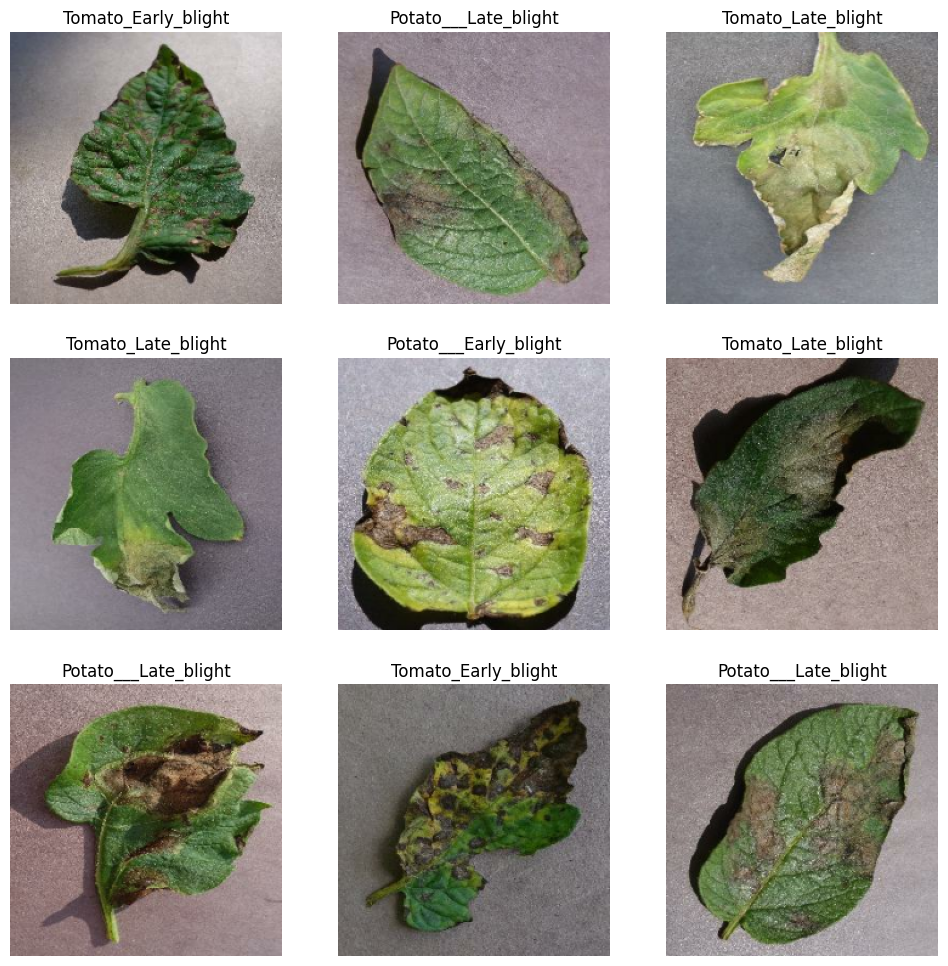

In [21]:
# =====================================
# 6. VISUALIZE SAMPLE IMAGES
# =====================================

plt.figure(figsize=(12,12))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [22]:
# =====================================
# 7. NORMALIZATION
# =====================================

normalization_layer = layers.Rescaling(1./255)

In [15]:
# =====================================
# 8. DATA AUGMENTATION
# =====================================

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2)

])

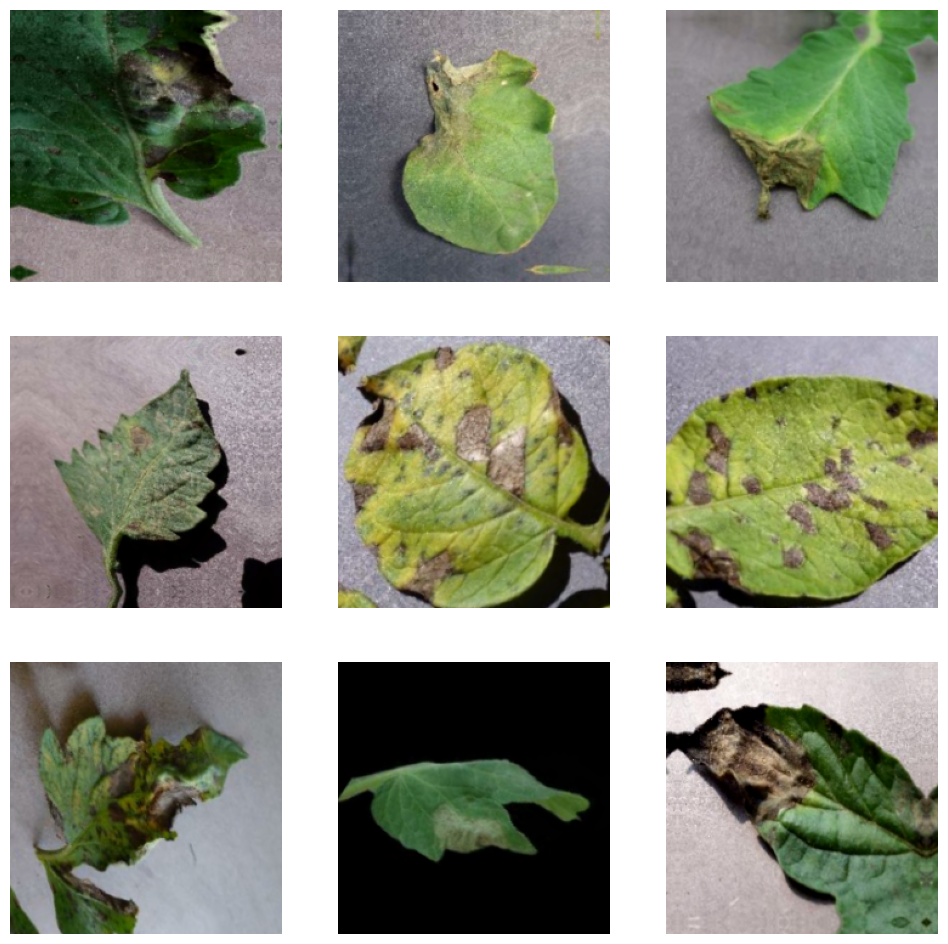

In [23]:
# =====================================
# 9. VISUALIZE AUGMENTATION
# =====================================

plt.figure(figsize=(12,12))

for images, _ in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented_images[i].numpy().astype("uint8"))

        plt.axis("off")

plt.show()

In [24]:
# =====================================
# 10. APPLY NORMALIZATION
# =====================================

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [25]:
# =====================================
# 11. PERFORMANCE OPTIMIZATION
# =====================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [26]:
# =====================================
# 12. FINAL DATASET CHECK
# =====================================

for image_batch, labels_batch in train_dataset.take(1):

    print("Image batch shape :", image_batch.shape)

    print("Labels batch shape :", labels_batch.shape)

Image batch shape : (32, 224, 224, 3)
Labels batch shape : (32,)


In [27]:
# =====================================
# 13. SAVE CLASS NAMES
# =====================================

with open("../models/class_names.txt", "w") as f:

    for item in class_names:
        f.write(f"{item}\n")

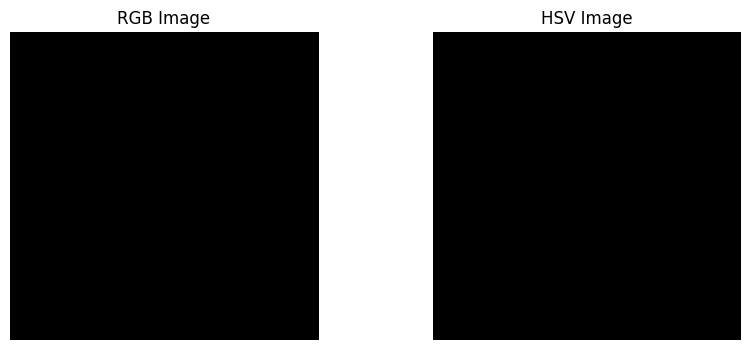

In [28]:
import cv2
import matplotlib.pyplot as plt

def convert_to_hsv(image):
    return cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# example visualization
for images, labels in train_dataset.take(1):
    img = images[0].numpy().astype("uint8")

    hsv_img = convert_to_hsv(img)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("RGB Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(hsv_img)
    plt.title("HSV Image")
    plt.axis("off")

    plt.show()

In [29]:
def apply_histogram_equalization(image):
    img_yuv = cv2.cvtColor(image, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    

In [30]:
def apply_gaussian_blur(image):
    return cv2.GaussianBlur(image, (5,5), 0)